<a href="https://colab.research.google.com/github/ishikadubey1105/HACK-O-WEEK-SEM-V/blob/main/week11_12_dimensionality_reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hack-o-Week — Weeks 11 & 12
## Dimensionality Reduction: PCA and t-SNE

**Datasets:** `student_habits_performance.csv` (our usual one) + `sklearn.datasets.load_digits`
(1,797 handwritten digits, 64 dimensions) — because dimensionality reduction only gets
*interesting* when you actually have a lot of dimensions.

Week 5–6 introduced PCA as an eigenvalue application. This notebook treats dimensionality
reduction as a topic in its own right: **why** high dimensions hurt, **how** PCA compresses
linearly, **how** t-SNE lays out neighbourhoods non-linearly, and — the part most tutorials
skip — **when each one lies to you**.

### Roadmap
| Part | Topic |
|---|---|
| A | The curse of dimensionality — why we need this at all |
| B | PCA end to end: variance, loadings, choosing `n_components`, reconstruction |
| C | PCA inside a pipeline (and whether it actually helps accuracy) |
| D | Where PCA fails — the non-linear cases |
| E | t-SNE: the intuition, step by step |
| F | Perplexity, randomness, and the caveats nobody tells you |
| G | PCA vs t-SNE side by side + a note on UMAP |

### 0 · Setup

In [ ]:
import os
import numpy as np
import pandas as pd

FILENAME = "student_habits_performance.csv"

# Works whether you run this notebook from the repo (notebooks/ folder),
# from the repo root, or in Google Colab.
CANDIDATES = [
    FILENAME,
    os.path.join("data", FILENAME),
    os.path.join("..", "data", FILENAME),
    os.path.join("/content", FILENAME),
]

DATA_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)

if DATA_PATH is None:
    try:  # running in Colab without the repo -> upload the CSV once
        from google.colab import files
        print("CSV not found. Please upload student_habits_performance.csv")
        files.upload()
        DATA_PATH = FILENAME
    except ImportError:
        raise FileNotFoundError(
            "Put student_habits_performance.csv in a data/ folder next to this notebook."
        )

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH, "| shape:", df.shape)
df.head()

Loaded: ../data/student_habits_performance.csv | shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
print("plotting configured")

plotting configured


In [ ]:
from sklearn.datasets import load_digits, make_swiss_roll, make_circles, make_moons
from sklearn.decomposition import PCA, KernelPCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import time

RANDOM_STATE = 42
print("imports ready")

imports ready


students: (1000, 7) -> 7 dimensions
digits  : (1797, 64) -> 64 dimensions, 10 classes


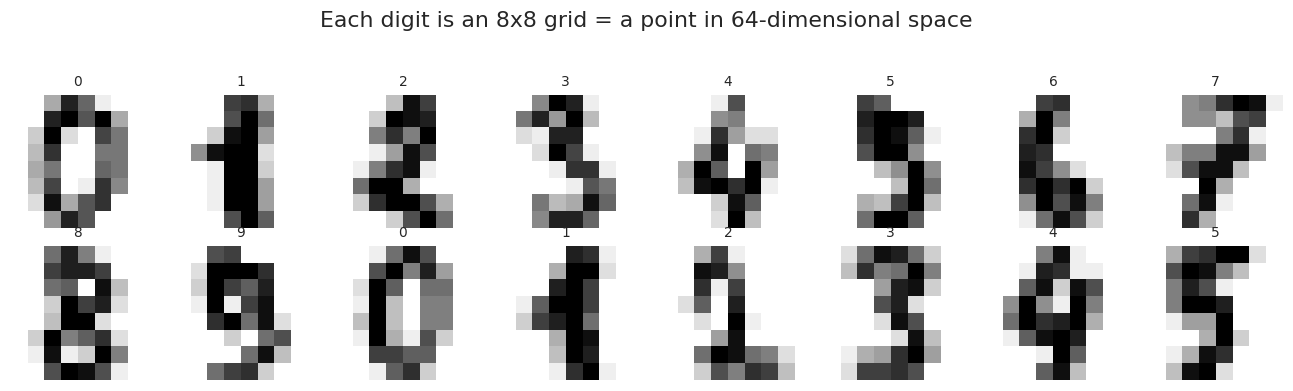

In [ ]:
# Dataset 1: our students (7 habit features)
CLUSTER_FEATURES = ["study_hours_per_day", "social_media_hours", "netflix_hours",
                    "attendance_percentage", "sleep_hours", "exercise_frequency",
                    "mental_health_rating"]
X_stu = df[CLUSTER_FEATURES].to_numpy(dtype=float)
y_stu = df["exam_score"].to_numpy(dtype=float)
X_stu_s = StandardScaler().fit_transform(X_stu)

# Dataset 2: handwritten digits — 8x8 images flattened to 64 numbers
digits = load_digits()
X_dig, y_dig = digits.data, digits.target
X_dig_s = StandardScaler().fit_transform(X_dig)

print("students:", X_stu_s.shape, "-> 7 dimensions")
print("digits  :", X_dig_s.shape, "-> 64 dimensions, 10 classes")

fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for ax, img, label in zip(axes.flat, digits.images, y_dig):
    ax.imshow(img, cmap="gray_r"); ax.set_title(str(label), fontsize=9); ax.axis("off")
fig.suptitle("Each digit is an 8x8 grid = a point in 64-dimensional space", y=1.04)
fig.tight_layout(); plt.show()

---
# Part A · The curse of dimensionality

Adding features feels free. It is not. As dimensions grow:

1. **Volume explodes.** To cover 10% of the range in each of `d` dimensions you need
   $0.1^d$ of the space — in 10-D that is one part in ten billion. Your data becomes
   *sparse* no matter how many rows you have.
2. **Distances stop discriminating.** The nearest and farthest neighbours converge to the
   same distance. Every point becomes equally far from every other point — which destroys
   KNN, K-Means, DBSCAN, and any kernel method.
3. **You need exponentially more data** to estimate anything reliably.

Let's measure effect #2 directly, because it is the one that actually breaks your models.

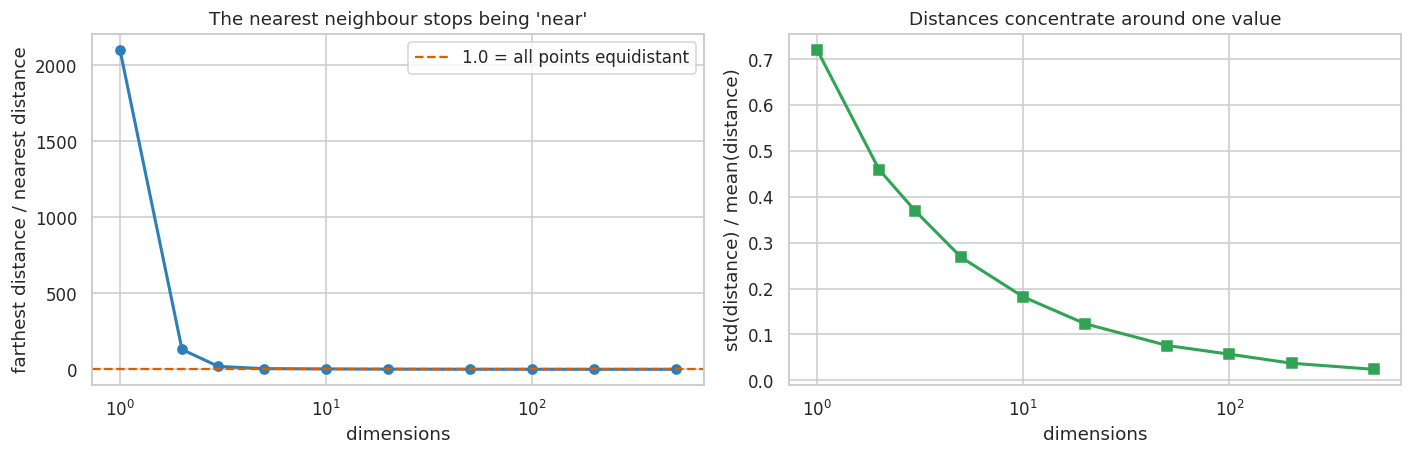

   1-D: farthest is 2103.43x the nearest distance
   2-D: farthest is 131.41x the nearest distance
   3-D: farthest is  20.15x the nearest distance
   5-D: farthest is   5.63x the nearest distance
  10-D: farthest is   3.55x the nearest distance
  20-D: farthest is   2.23x the nearest distance
  50-D: farthest is   1.64x the nearest distance
 100-D: farthest is   1.39x the nearest distance
 200-D: farthest is   1.28x the nearest distance
 500-D: farthest is   1.16x the nearest distance


In [ ]:
rng = np.random.default_rng(RANDOM_STATE)
dims = [1, 2, 3, 5, 10, 20, 50, 100, 200, 500]
n_points = 500
ratios, spreads = [], []

for d in dims:
    pts = rng.uniform(0, 1, size=(n_points, d))
    # distance from the first point to every other point
    dist = np.linalg.norm(pts[1:] - pts[0], axis=1)
    ratios.append(dist.max() / dist.min())
    spreads.append(dist.std() / dist.mean())     # relative spread

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
axes[0].plot(dims, ratios, "o-", color="#2c7fb8", lw=2)
axes[0].axhline(1, ls="--", color="#d95f02", label="1.0 = all points equidistant")
axes[0].set_xscale("log"); axes[0].set_xlabel("dimensions")
axes[0].set_ylabel("farthest distance / nearest distance")
axes[0].set_title("The nearest neighbour stops being 'near'")
axes[0].legend()

axes[1].plot(dims, spreads, "s-", color="#31a354", lw=2)
axes[1].set_xscale("log"); axes[1].set_xlabel("dimensions")
axes[1].set_ylabel("std(distance) / mean(distance)")
axes[1].set_title("Distances concentrate around one value")
fig.tight_layout(); plt.show()

for d, r in zip(dims, ratios):
    print(f"{d:>4}-D: farthest is {r:6.2f}x the nearest distance")

In 1-D the farthest point is over a *thousand* times farther than the nearest. By 50-D the
ratio is down to 1.6×, and by 500-D it is **1.16×** — the farthest point is barely 16%
farther away than the closest one. "Nearest neighbour" has stopped meaning anything.

Now watch it break a real model.

   64 dims (   0 of them noise): KNN accuracy 0.9794
   74 dims (  10 of them noise): KNN accuracy 0.9660
  114 dims (  50 of them noise): KNN accuracy 0.9343
  164 dims ( 100 of them noise): KNN accuracy 0.8959
  364 dims ( 300 of them noise): KNN accuracy 0.7501


  664 dims ( 600 of them noise): KNN accuracy 0.6060
 1064 dims (1000 of them noise): KNN accuracy 0.4947


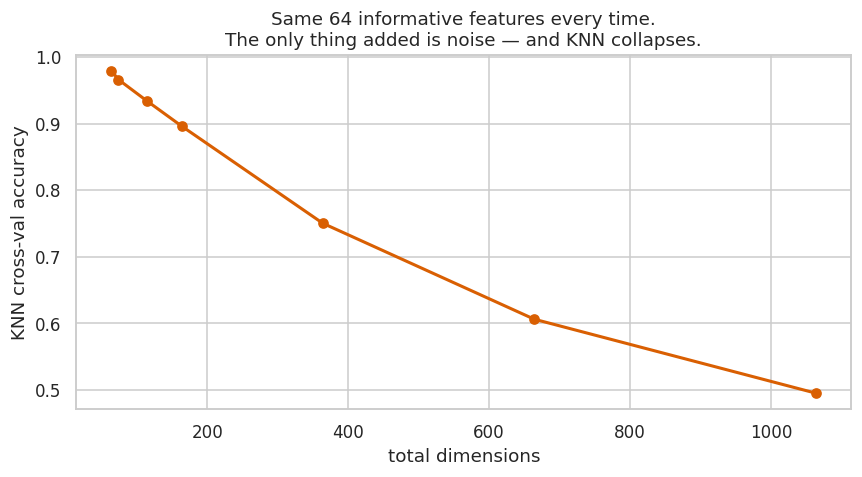

In [ ]:
# Take the digits, then bury them under pure-noise features
base_acc, dims_tested = [], [0, 10, 50, 100, 300, 600, 1000]
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

for n_noise in dims_tested:
    if n_noise:
        noise = rng.normal(0, 1, size=(len(X_dig_s), n_noise))
        Xn = np.hstack([X_dig_s, noise])
    else:
        Xn = X_dig_s
    acc = cross_val_score(KNeighborsClassifier(5), Xn, y_dig, cv=cv).mean()
    base_acc.append(acc)
    print(f"{64 + n_noise:>5} dims ({n_noise:>4} of them noise): KNN accuracy {acc:.4f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot([64 + n for n in dims_tested], base_acc, "o-", color="#d95f02", lw=2)
ax.set_xlabel("total dimensions"); ax.set_ylabel("KNN cross-val accuracy")
ax.set_title("Same 64 informative features every time.\nThe only thing added is noise — "
             "and KNN collapses.")
fig.tight_layout(); plt.show()

> **This is the whole motivation.** Dimensionality reduction is not just for making pretty
> 2-D pictures. It removes the directions that carry no signal, so distance-based models
> can work again, training gets faster, and storage shrinks.
>
> Two families:
> - **Feature selection** — *keep* a subset of the original columns (Lasso, Week 7–8).
> - **Feature extraction** — *build* new columns from combinations of the old ones. PCA and
>   t-SNE both live here.

---
# Part B · PCA, end to end

**The one-sentence intuition:** rotate the coordinate axes so the first new axis points
along the direction the data spreads out the most, the second along the next-most (at right
angles to the first), and so on. Then throw away the last few axes, where there is barely
any spread to lose.

Formally: the principal components are the **eigenvectors of the covariance matrix**, and
their **eigenvalues** are the variance along each one (Week 5–6). Equivalently, PCA finds
the projection that minimises squared reconstruction error — the same least-squares idea
as linear regression, but with no target variable.

### The three rules

1. **Standardise first** (unless every feature is already in the same unit). PCA maximises
   *variance*, and variance depends on units — measure height in millimetres instead of
   metres and it dominates every component.
2. **Components are orthogonal** and ordered by variance explained. PC1 ⟂ PC2 ⟂ PC3…
3. **Signs are arbitrary.** A component flipped end-for-end is the same component; do not
   read meaning into the sign, only into the *relative* loadings.

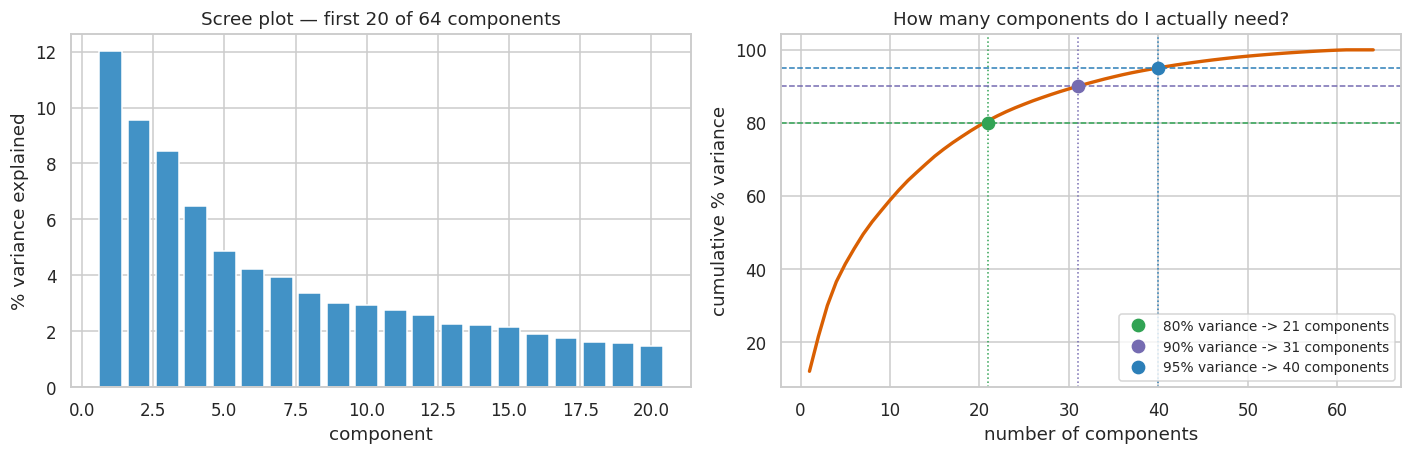

PC1 alone explains 12.0%; the first 10 explain 58.9%
  80% of the variance needs 21 of 64 components
  90% of the variance needs 31 of 64 components
  95% of the variance needs 40 of 64 components
  99% of the variance needs 54 of 64 components


In [ ]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X_dig_s)

evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
axes[0].bar(range(1, 21), evr[:20] * 100, color="#4292c6")
axes[0].set_xlabel("component"); axes[0].set_ylabel("% variance explained")
axes[0].set_title("Scree plot — first 20 of 64 components")

axes[1].plot(range(1, len(cum) + 1), cum * 100, lw=2.2, color="#d95f02")
for thresh, colr in [(0.80, "#31a354"), (0.90, "#756bb1"), (0.95, "#2c7fb8")]:
    k = int(np.argmax(cum >= thresh)) + 1
    axes[1].axhline(thresh * 100, ls="--", lw=1, color=colr)
    axes[1].axvline(k, ls=":", lw=1, color=colr)
    axes[1].plot(k, thresh * 100, "o", color=colr, ms=8,
                 label=f"{thresh:.0%} variance -> {k} components")
axes[1].set_xlabel("number of components"); axes[1].set_ylabel("cumulative % variance")
axes[1].set_title("How many components do I actually need?")
axes[1].legend(loc="lower right", fontsize=9)
fig.tight_layout(); plt.show()

print(f"PC1 alone explains {evr[0]:.1%}; the first 10 explain {cum[9]:.1%}")
for t in [0.80, 0.90, 0.95, 0.99]:
    print(f"  {t:.0%} of the variance needs {int(np.argmax(cum >= t)) + 1:>2} "
          f"of 64 components")

### Choosing `n_components` — four ways

| Method | How | When |
|---|---|---|
| **Variance threshold** | `PCA(n_components=0.95)` — sklearn picks `k` for you | the usual default |
| **Elbow / scree** | eyeball where the bar chart flattens | quick, subjective |
| **Kaiser criterion** | keep components with eigenvalue > 1 (on standardised data) | classical stats |
| **Downstream CV** | try several `k`, cross-validate the model that follows | **best when PCA feeds a model** |

`PCA(n_components=0.95)` is the line you will write most often.

In [ ]:
# sklearn accepts a FLOAT as a variance target — very convenient
pca95 = PCA(n_components=0.95, random_state=RANDOM_STATE).fit(X_dig_s)
print(f"n_components=0.95 -> kept {pca95.n_components_} components "
      f"({pca95.n_components_/64:.0%} of the original size)")
print(f"actual variance retained: {pca95.explained_variance_ratio_.sum():.4f}")

# Kaiser criterion: eigenvalue > 1 on standardised data
kaiser = int((pca_full.explained_variance_ > 1).sum())
print(f"\nKaiser criterion (eigenvalue > 1) -> {kaiser} components")

print(f"\nCompression: {X_dig_s.nbytes/1024:.0f} KB -> "
      f"{pca95.transform(X_dig_s).nbytes/1024:.0f} KB")

n_components=0.95 -> kept 40 components (62% of the original size)
actual variance retained: 0.9508

Kaiser criterion (eigenvalue > 1) -> 17 components

Compression: 898 KB -> 562 KB


## B1 · Reading the components: loadings and eigen-images

A component is a **weighted recipe of the original features**. For the digits, each
component is itself a 64-pixel image — an "eigen-digit". PC1 is the single image that,
scaled up and down, best explains how digits differ from the average digit.

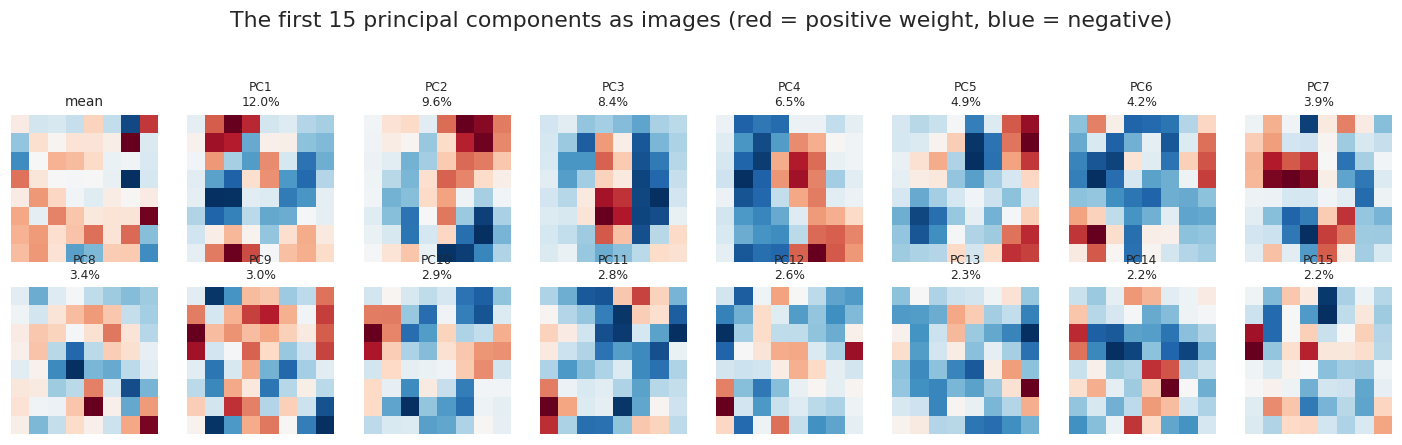

In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(13, 3.8))
axes[0, 0].imshow(pca_full.mean_.reshape(8, 8), cmap="RdBu_r")
axes[0, 0].set_title("mean", fontsize=9); axes[0, 0].axis("off")
for i, ax in enumerate(axes.flat[1:]):
    ax.imshow(pca_full.components_[i].reshape(8, 8), cmap="RdBu_r")
    ax.set_title(f"PC{i+1}\n{evr[i]:.1%}", fontsize=8); ax.axis("off")
fig.suptitle("The first 15 principal components as images "
             "(red = positive weight, blue = negative)", y=1.06)
fig.tight_layout(); plt.show()

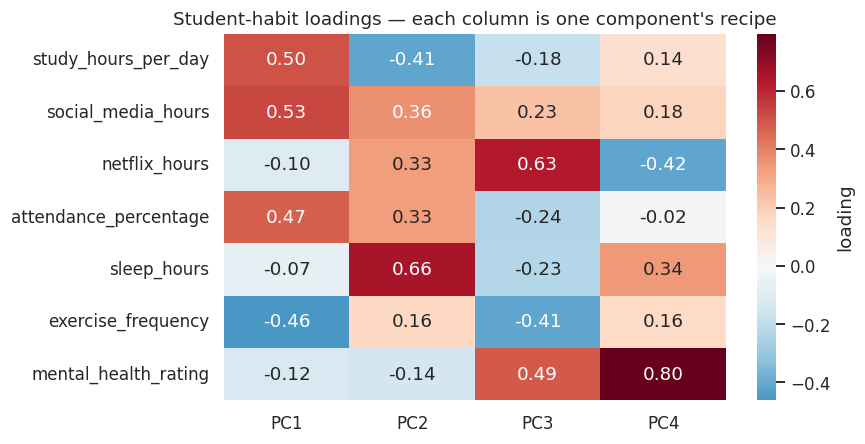

explained variance per component: [15.5 14.9 14.6 14.2 13.9 13.5 13.4] %

How to read a component: look at which features have LARGE loadings of the
SAME sign (they move together) vs large loadings of OPPOSITE sign (they trade off).


In [ ]:
# The same idea on the student data, where the features have NAMES
pca_stu = PCA(random_state=RANDOM_STATE).fit(X_stu_s)
loadings = pd.DataFrame(
    pca_stu.components_[:4].T.round(3),
    index=CLUSTER_FEATURES, columns=[f"PC{i+1}" for i in range(4)])

fig, ax = plt.subplots(figsize=(8, 4.2))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "loading"})
ax.set_title("Student-habit loadings — each column is one component's recipe")
fig.tight_layout(); plt.show()

print("explained variance per component:",
      (pca_stu.explained_variance_ratio_ * 100).round(1), "%")
print("\nHow to read a component: look at which features have LARGE loadings of the")
print("SAME sign (they move together) vs large loadings of OPPOSITE sign (they trade off).")

### The biplot

A biplot draws the data in PC space *and* overlays the original feature axes as arrows.
Arrow direction = which way that feature increases; arrow length = how well the first two
components capture it.

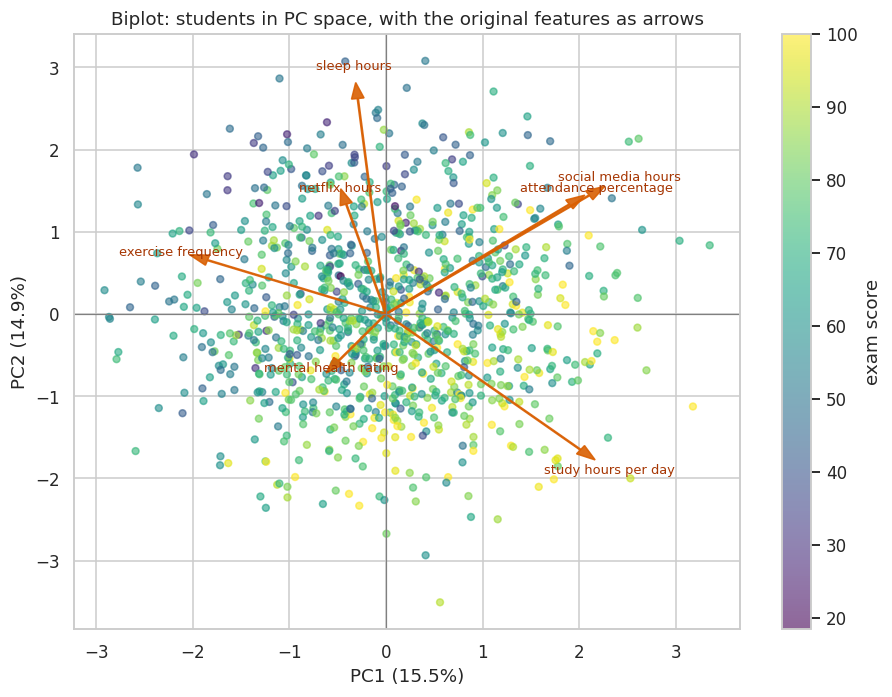

Arrows pointing the SAME way   -> those habits are positively correlated
Arrows pointing OPPOSITE ways  -> negatively correlated
Arrows at ~90 degrees          -> roughly independent

Here the arrows are spread almost evenly around the circle: these habits are
close to mutually independent, which is why PC1 only captures ~15.5%.


In [ ]:
Z_stu = pca_stu.transform(X_stu_s)[:, :2]

fig, ax = plt.subplots(figsize=(8.5, 6.5))
sc = ax.scatter(Z_stu[:, 0], Z_stu[:, 1], c=y_stu, cmap="viridis", s=20, alpha=0.6)

scale = 4.0
for i, feat in enumerate(CLUSTER_FEATURES):
    vx, vy = pca_stu.components_[0, i] * scale, pca_stu.components_[1, i] * scale
    ax.arrow(0, 0, vx, vy, color="#d95f02", width=0.012, head_width=0.13, alpha=0.9)
    ax.text(vx * 1.15, vy * 1.15, feat.replace("_", " "), color="#a63603",
            fontsize=8.5, ha="center", va="center")

ax.set_xlabel(f"PC1 ({pca_stu.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_stu.explained_variance_ratio_[1]:.1%})")
ax.set_title("Biplot: students in PC space, with the original features as arrows")
fig.colorbar(sc, ax=ax, label="exam score")
ax.axhline(0, color="gray", lw=.8); ax.axvline(0, color="gray", lw=.8)
fig.tight_layout(); plt.show()

print("Arrows pointing the SAME way   -> those habits are positively correlated")
print("Arrows pointing OPPOSITE ways  -> negatively correlated")
print("Arrows at ~90 degrees          -> roughly independent")
print("\nHere the arrows are spread almost evenly around the circle: these habits are")
print("close to mutually independent, which is why PC1 only captures ~15.5%.")

## B2 · Reconstruction — what does "losing variance" actually cost?

`inverse_transform` projects back into the original space. The gap between the original and
the reconstruction is exactly the variance you threw away. For images you can *see* it.

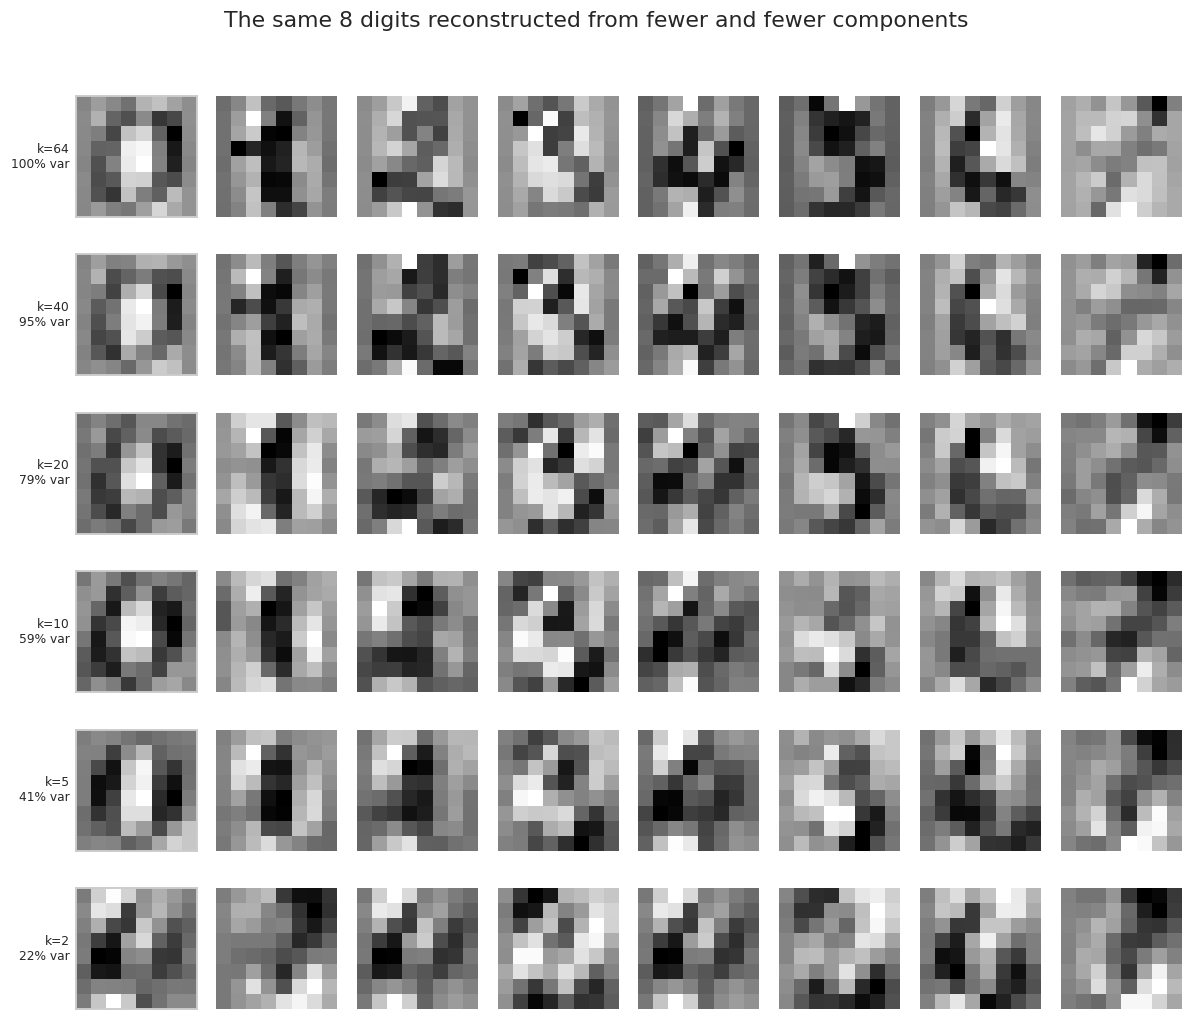

In [ ]:
n_show = 8
component_counts = [64, 40, 20, 10, 5, 2]

fig, axes = plt.subplots(len(component_counts), n_show,
                         figsize=(11, 1.55 * len(component_counts)))
for row, k in enumerate(component_counts):
    p = PCA(n_components=k, random_state=RANDOM_STATE).fit(X_dig_s)
    recon = p.inverse_transform(p.transform(X_dig_s[:n_show]))
    err = np.mean((X_dig_s[:n_show] - recon) ** 2)
    for col in range(n_show):
        axes[row, col].imshow(recon[col].reshape(8, 8), cmap="gray_r")
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(f"k={k}")
    axes[row, 0].axis("on"); axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    axes[row, 0].set_ylabel(f"k={k}\n{p.explained_variance_ratio_.sum():.0%} var",
                            fontsize=8, rotation=0, ha="right", va="center")
fig.suptitle("The same 8 digits reconstructed from fewer and fewer components", y=1.01)
fig.tight_layout(); plt.show()

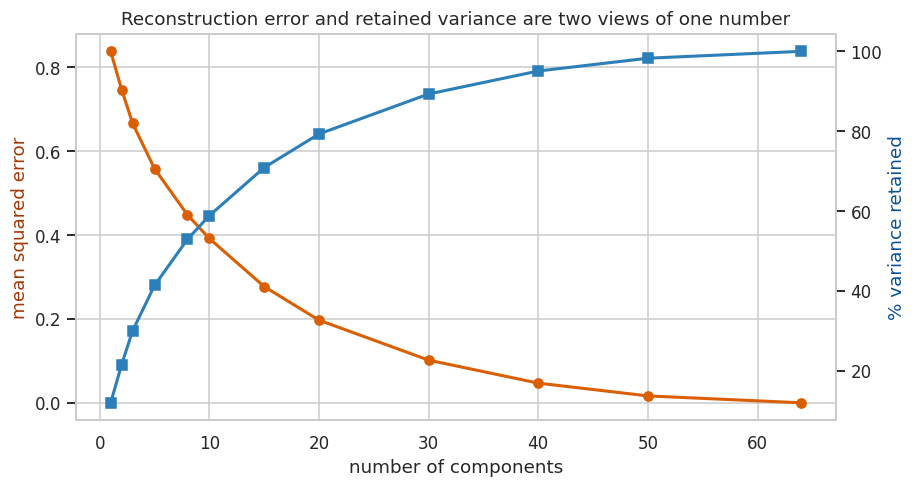

Note: error + retained variance ≈ constant. 'Explained variance' IS
'how little reconstruction error you will have'.


In [ ]:
# Quantify it: reconstruction error vs number of components
ks = [1, 2, 3, 5, 8, 10, 15, 20, 30, 40, 50, 64]
errors, variances = [], []
for k in ks:
    p = PCA(n_components=k, random_state=RANDOM_STATE).fit(X_dig_s)
    recon = p.inverse_transform(p.transform(X_dig_s))
    errors.append(np.mean((X_dig_s - recon) ** 2))
    variances.append(p.explained_variance_ratio_.sum())

fig, ax1 = plt.subplots(figsize=(8.5, 4.6))
ax1.plot(ks, errors, "o-", color="#d95f02", lw=2, label="reconstruction MSE")
ax1.set_xlabel("number of components"); ax1.set_ylabel("mean squared error", color="#a63603")
ax2 = ax1.twinx()
ax2.plot(ks, np.array(variances) * 100, "s-", color="#2c7fb8", lw=2,
         label="variance retained")
ax2.set_ylabel("% variance retained", color="#08519c"); ax2.grid(False)
ax1.set_title("Reconstruction error and retained variance are two views of one number")
fig.tight_layout(); plt.show()

print("Note: error + retained variance ≈ constant. 'Explained variance' IS")
print("'how little reconstruction error you will have'.")

### A real use: PCA as a denoiser

Noise is spread evenly across *all* directions; signal is concentrated in a few. Keep the
top components and you keep mostly signal — the noise gets left behind in the discarded
directions.

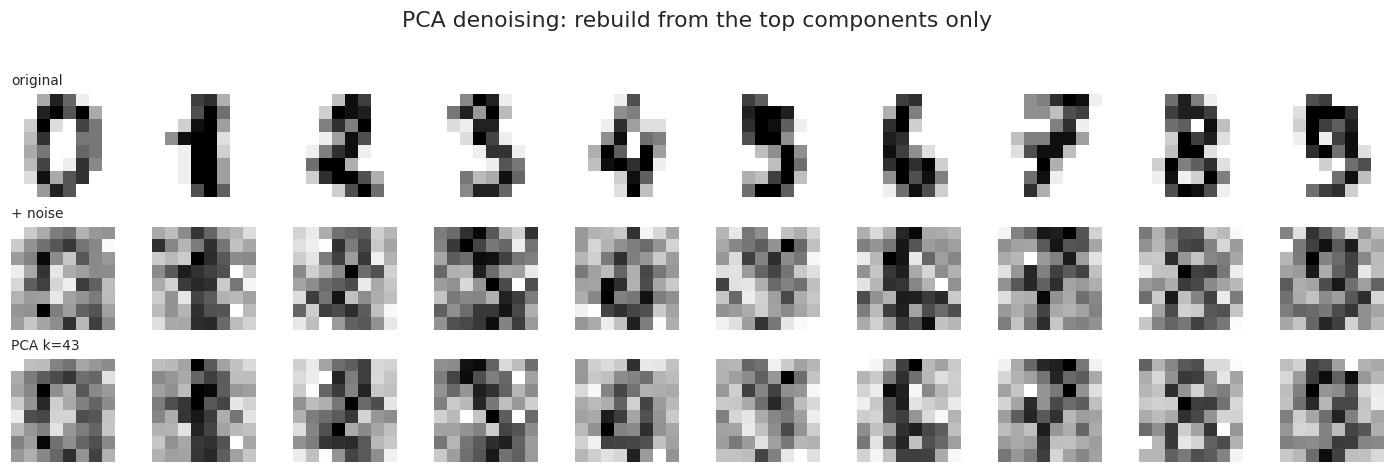

MSE noisy vs clean    :    35.85
MSE denoised vs clean :    26.60


In [ ]:
noisy = X_dig + rng.normal(0, 6, size=X_dig.shape)
p_denoise = PCA(n_components=0.80, random_state=RANDOM_STATE).fit(noisy)
denoised = p_denoise.inverse_transform(p_denoise.transform(noisy))

fig, axes = plt.subplots(3, 10, figsize=(13, 4.2))
for col in range(10):
    axes[0, col].imshow(X_dig[col].reshape(8, 8), cmap="gray_r")
    axes[1, col].imshow(noisy[col].reshape(8, 8), cmap="gray_r")
    axes[2, col].imshow(denoised[col].reshape(8, 8), cmap="gray_r")
    for r in range(3):
        axes[r, col].axis("off")
for r, lab in enumerate(["original", "+ noise", f"PCA k={p_denoise.n_components_}"]):
    axes[r, 0].set_title(lab, fontsize=9, loc="left")
fig.suptitle("PCA denoising: rebuild from the top components only", y=1.02)
fig.tight_layout(); plt.show()

print(f"MSE noisy vs clean    : {np.mean((noisy - X_dig)**2):8.2f}")
print(f"MSE denoised vs clean : {np.mean((denoised - X_dig)**2):8.2f}")

---
# Part C · PCA in a pipeline — does it actually help?

PCA has a `transform()` method, so it is a normal sklearn transformer and belongs
**inside a Pipeline**, fitted on the training fold only (Week 9–10's leakage rule applies
exactly as before — fitting PCA on all the data before splitting is a classic leak).

The honest question: does compressing to `k` components make the downstream model *better*,
or just *faster*? The answer depends on the model.

In [ ]:
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(
    X_dig, y_dig, test_size=0.25, random_state=RANDOM_STATE, stratify=y_dig)

def timed_cv(pipe, X, y, name):
    t0 = time.perf_counter()
    s = cross_val_score(pipe, X, y, cv=cv, n_jobs=-1)
    return {"model": name, "cv_accuracy": s.mean(), "std": s.std(),
            "seconds": time.perf_counter() - t0}

rows = []
for k in [None, 40, 20, 10, 5, 2]:
    steps = [("scale", StandardScaler())]
    label = "no PCA (64 dims)"
    if k is not None:
        steps.append(("pca", PCA(n_components=k, random_state=RANDOM_STATE)))
        label = f"PCA k={k}"
    steps.append(("knn", KNeighborsClassifier(5)))
    rows.append(timed_cv(Pipeline(steps), X_dig, y_dig, label))

knn_df = pd.DataFrame(rows).set_index("model").round(4)
print("KNN on digits:\n")
print(knn_df.to_string())

KNN on digits:

                  cv_accuracy     std  seconds
model                                         
no PCA (64 dims)       0.9789  0.0063   1.3479
PCA k=40               0.9766  0.0086   0.0483
PCA k=20               0.9722  0.0079   0.0456
PCA k=10               0.9360  0.0092   0.0473
PCA k=5                0.8726  0.0082   0.0349
PCA k=2                0.5292  0.0120   0.0361


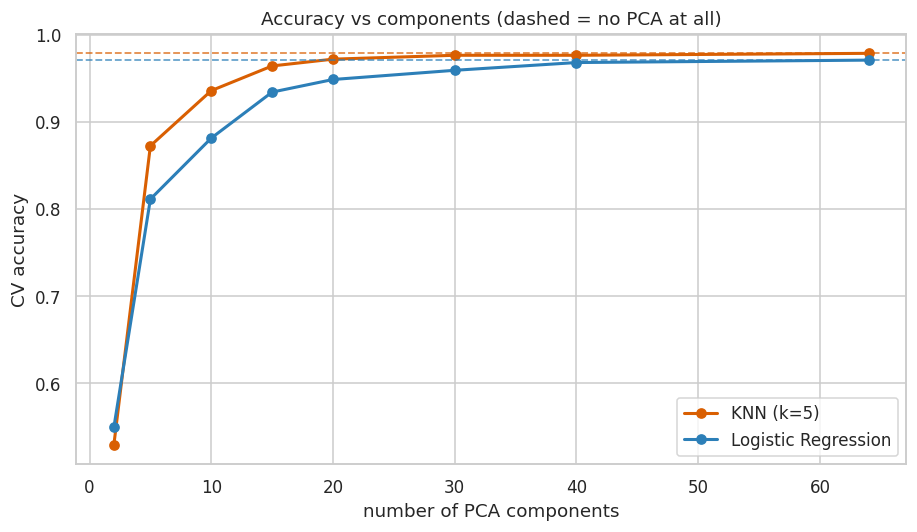

    KNN (k=5)  Logistic Regression
2      0.5292               0.5492
5      0.8726               0.8114
10     0.9360               0.8815
15     0.9644               0.9343
20     0.9722               0.9488
30     0.9766               0.9594
40     0.9766               0.9683
64     0.9789               0.9711


In [ ]:
# Same sweep, but a finer grid, and for two different classifiers
k_grid = [2, 5, 10, 15, 20, 30, 40, 64]
res = {"KNN (k=5)": [], "Logistic Regression": []}
for k in k_grid:
    for name, clf in [("KNN (k=5)", KNeighborsClassifier(5)),
                      ("Logistic Regression", LogisticRegression(max_iter=3000))]:
        pipe = Pipeline([("scale", StandardScaler()),
                         ("pca", PCA(n_components=k, random_state=RANDOM_STATE)),
                         ("clf", clf)])
        res[name].append(cross_val_score(pipe, X_dig, y_dig, cv=cv, n_jobs=-1).mean())

fig, ax = plt.subplots(figsize=(8.5, 5))
for (name, scores), colr in zip(res.items(), ["#d95f02", "#2c7fb8"]):
    ax.plot(k_grid, scores, "o-", lw=2, color=colr, label=name)
    baseline = cross_val_score(
        Pipeline([("scale", StandardScaler()),
                  ("clf", KNeighborsClassifier(5) if "KNN" in name
                          else LogisticRegression(max_iter=3000))]),
        X_dig, y_dig, cv=cv, n_jobs=-1).mean()
    ax.axhline(baseline, ls="--", lw=1.2, color=colr, alpha=0.7)
ax.set_xlabel("number of PCA components"); ax.set_ylabel("CV accuracy")
ax.set_title("Accuracy vs components (dashed = no PCA at all)")
ax.legend(); fig.tight_layout(); plt.show()

print(pd.DataFrame(res, index=k_grid).round(4).to_string())

Read those two tables carefully — the honest reading is more interesting than the usual
"PCA makes everything better" story:

- **PCA did not improve accuracy on clean digits.** Full 64 dims gives KNN 0.979; the best
  PCA setting gives 0.977. Every component you drop costs a little.
- **But it was ~30× faster** (1.2s → 0.04s) for that 0.002 loss. On a real dataset that
  trade is a bargain.
- **KNN degrades more gracefully than logistic regression** as `k` shrinks. At k=5 KNN
  holds 0.87 while logistic regression is down to 0.81 — a linear model spreads its
  reliance across all directions, so losing any of them hurts immediately.

So where does PCA actually *improve* accuracy? Exactly where Part A predicted: when many
of your dimensions are **noise**. Let's rebuild the noisy digits and try again.

noisy dataset: (1797, 364)



KNN on NOISY digits:

                   cv_accuracy
model                         
no PCA (364 dims)       0.7568
PCA k=10                0.8943
PCA k=20                0.8675
PCA k=30                0.8525
PCA k=40                0.8381
PCA k=60                0.8119


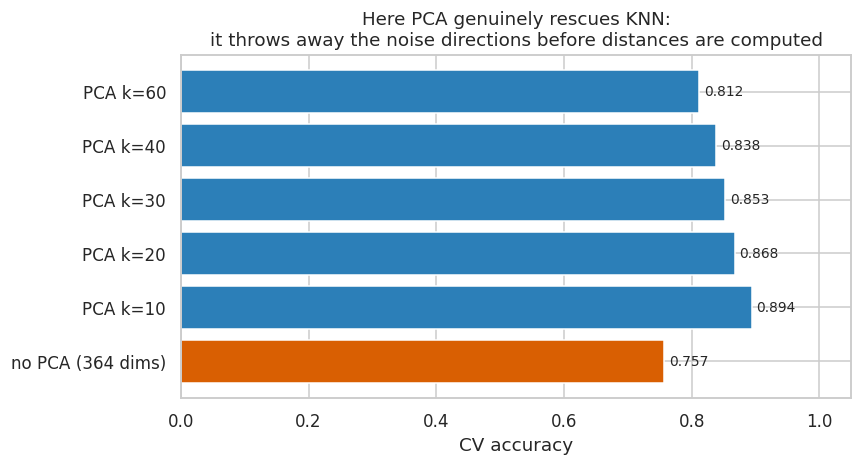

In [ ]:
# 64 real features + 300 pure-noise features — the Part A disaster case
X_noisy = np.hstack([X_dig_s, rng.normal(0, 1, size=(len(X_dig_s), 300))])
print("noisy dataset:", X_noisy.shape)

rows = [{"model": "no PCA (364 dims)",
         "cv_accuracy": cross_val_score(
             Pipeline([("scale", StandardScaler()), ("knn", KNeighborsClassifier(5))]),
             X_noisy, y_dig, cv=cv, n_jobs=-1).mean()}]
for k in [10, 20, 30, 40, 60]:
    s = cross_val_score(
        Pipeline([("scale", StandardScaler()),
                  ("pca", PCA(n_components=k, random_state=RANDOM_STATE)),
                  ("knn", KNeighborsClassifier(5))]),
        X_noisy, y_dig, cv=cv, n_jobs=-1).mean()
    rows.append({"model": f"PCA k={k}", "cv_accuracy": s})

noisy_df = pd.DataFrame(rows).set_index("model").round(4)
print("\nKNN on NOISY digits:\n")
print(noisy_df.to_string())

fig, ax = plt.subplots(figsize=(8, 4.4))
bars = ax.barh(noisy_df.index, noisy_df["cv_accuracy"],
               color=["#d95f02"] + ["#2c7fb8"] * (len(noisy_df) - 1))
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_xlim(0, 1.05); ax.set_xlabel("CV accuracy")
ax.set_title("Here PCA genuinely rescues KNN:\nit throws away the noise directions "
             "before distances are computed")
fig.tight_layout(); plt.show()

**There it is: 0.76 → 0.89, a ~14-point gain**, just by projecting onto 10 components first.
PCA found that the 300 noise dimensions carried almost no variance and discarded them.

**The rule to remember:**

| Situation | Does PCA help accuracy? |
|---|---|
| Many redundant or noisy features | **Yes**, often a lot |
| Distance-based model (KNN, K-Means, DBSCAN, SVM-RBF) | **Yes** — distance gets meaningful again |
| Few, independent, informative features | **No** — you only lose signal |
| Well-regularised linear model | Rarely — the regulariser already handles it |
| Tree-based model (RF, XGBoost) | Often **hurts** — trees are scale- and rotation-agnostic, and PCA destroys interpretable splits |

And regardless of accuracy, PCA almost always helps **speed** and **memory**.

In [ ]:
# The same question on the student data — where PCA has nothing to compress
rows = []
for k in [None, 5, 3, 2]:
    steps = [("scale", StandardScaler())]
    label = "no PCA (7 dims)"
    if k:
        steps.append(("pca", PCA(n_components=k, random_state=RANDOM_STATE)))
        label = f"PCA k={k}"
    steps.append(("clf", LogisticRegression(max_iter=2000)))
    y_pass = (y_stu >= 60).astype(int)
    s = cross_val_score(Pipeline(steps), X_stu, y_pass, cv=cv, scoring="roc_auc", n_jobs=-1)
    rows.append({"model": label, "cv_roc_auc": s.mean(), "std": s.std()})

print("Pass/fail prediction on student habits:\n")
print(pd.DataFrame(rows).set_index("model").round(4).to_string())
print("""
PCA loses accuracy here, and that is expected. With 7 near-independent features
there is no redundancy to remove — every component you drop is real signal. PCA pays
off when features are MANY and CORRELATED. Ours are few and independent.""")

Pass/fail prediction on student habits:

                 cv_roc_auc     std
model                              
no PCA (7 dims)      0.9736  0.0061
PCA k=5              0.8040  0.0821
PCA k=3              0.7610  0.0727
PCA k=2              0.6686  0.0881

PCA loses accuracy here, and that is expected. With 7 near-independent features
there is no redundancy to remove — every component you drop is real signal. PCA pays
off when features are MANY and CORRELATED. Ours are few and independent.


---
# Part D · Where PCA fails

PCA can only apply a **rotation and a projection** — a linear map. If the structure in your
data is curved, PCA cannot unfold it, no matter how many components you keep.

These three shapes are the standard counterexamples.

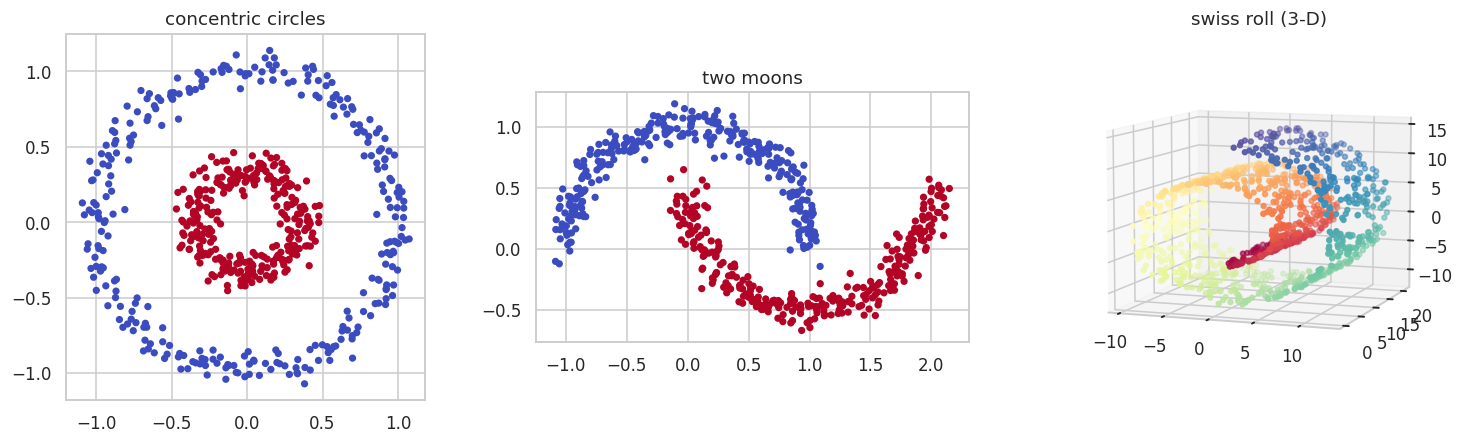

In [ ]:
X_circ, y_circ = make_circles(n_samples=600, factor=0.35, noise=0.06,
                              random_state=RANDOM_STATE)
X_moon, y_moon = make_moons(n_samples=600, noise=0.07, random_state=RANDOM_STATE)
X_roll, color_roll = make_swiss_roll(n_samples=1200, noise=0.1, random_state=RANDOM_STATE)

fig = plt.figure(figsize=(14, 4.2))
ax = fig.add_subplot(1, 3, 1)
ax.scatter(*X_circ.T, c=y_circ, cmap="coolwarm", s=14); ax.set_title("concentric circles")
ax.set_aspect("equal")
ax = fig.add_subplot(1, 3, 2)
ax.scatter(*X_moon.T, c=y_moon, cmap="coolwarm", s=14); ax.set_title("two moons")
ax.set_aspect("equal")
ax = fig.add_subplot(1, 3, 3, projection="3d")
ax.scatter(X_roll[:, 0], X_roll[:, 1], X_roll[:, 2], c=color_roll, cmap="Spectral", s=10)
ax.set_title("swiss roll (3-D)"); ax.view_init(8, -70)
fig.tight_layout(); plt.show()

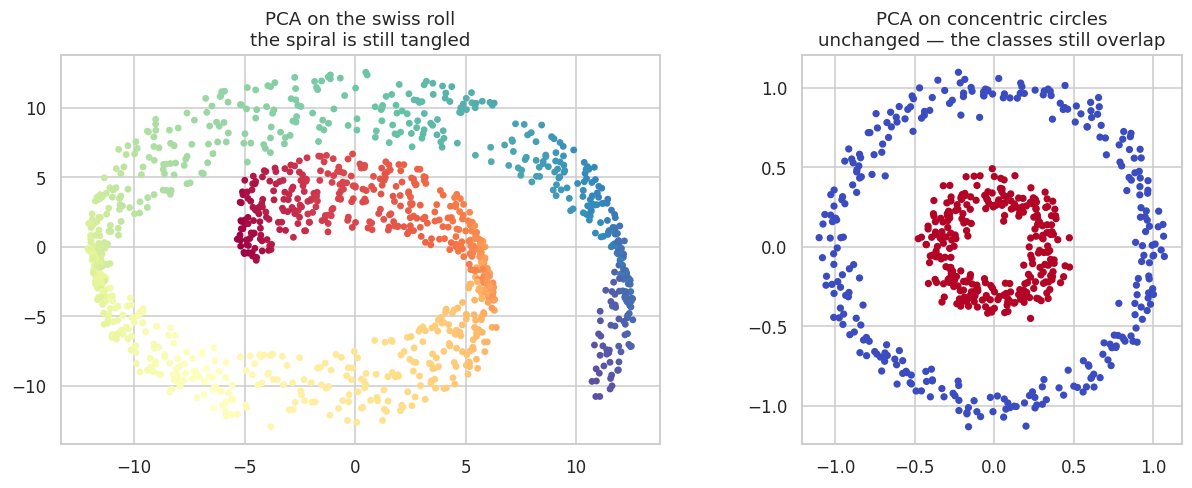

PCA preserves GLOBAL variance but cannot bend space. Points that are far apart
ALONG the manifold but close THROUGH it stay close after projection.


In [ ]:
# What does PCA do to the swiss roll? It photographs it from the best angle —
# which still leaves the roll rolled up.
Z_pca_roll = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_roll)
Z_pca_circ = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_circ)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].scatter(*Z_pca_roll.T, c=color_roll, cmap="Spectral", s=12)
axes[0].set_title("PCA on the swiss roll\nthe spiral is still tangled")
axes[1].scatter(*Z_pca_circ.T, c=y_circ, cmap="coolwarm", s=14)
axes[1].set_title("PCA on concentric circles\nunchanged — the classes still overlap")
axes[1].set_aspect("equal")
fig.tight_layout(); plt.show()

print("PCA preserves GLOBAL variance but cannot bend space. Points that are far apart")
print("ALONG the manifold but close THROUGH it stay close after projection.")

> **Manifold learning** is the family of methods that *can* bend space: t-SNE, UMAP,
> Isomap, LLE, and kernel PCA. They assume your high-dimensional data actually lies on a
> lower-dimensional curved surface (a *manifold*) and try to flatten that surface out.

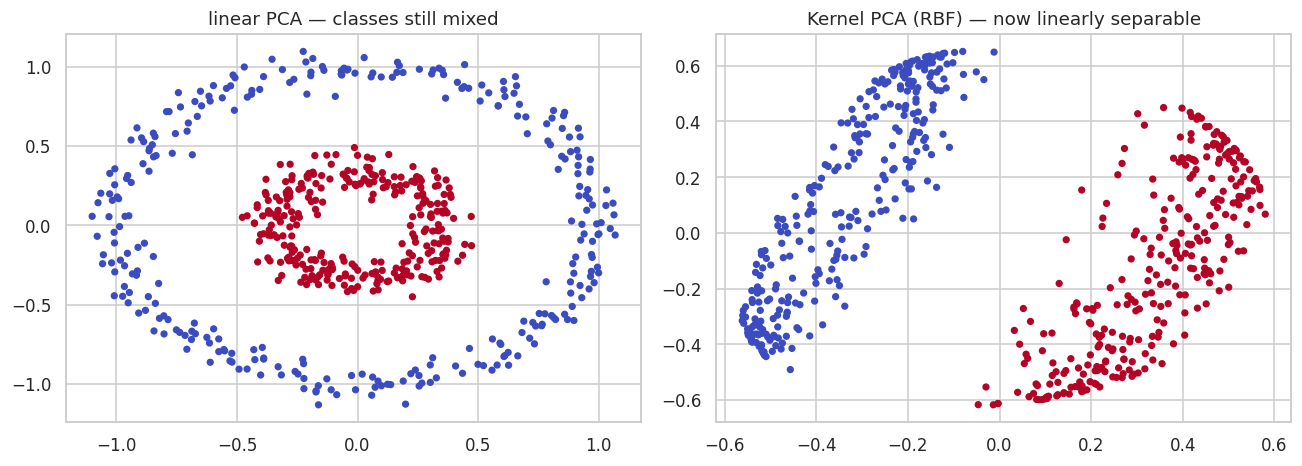

In [ ]:
# Kernel PCA — the "PCA but non-linear" halfway house, for comparison
kpca = KernelPCA(n_components=2, kernel="rbf", gamma=2.0, random_state=RANDOM_STATE)
Z_kpca = kpca.fit_transform(X_circ)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].scatter(*Z_pca_circ.T, c=y_circ, cmap="coolwarm", s=14)
axes[0].set_title("linear PCA — classes still mixed")
axes[1].scatter(*Z_kpca.T, c=y_circ, cmap="coolwarm", s=14)
axes[1].set_title("Kernel PCA (RBF) — now linearly separable")
fig.tight_layout(); plt.show()

---
# Part E · t-SNE — the intuition

**t-Distributed Stochastic Neighbour Embedding.** Its goal is completely different from
PCA's:

| | PCA asks | t-SNE asks |
|---|---|---|
| Goal | keep as much **variance** as possible | keep each point's **neighbours** as neighbours |
| Scope | **global** structure | **local** structure |
| Map | one fixed linear projection | a new layout, optimised per dataset |

### How it works, in four steps

**1. Turn distances into probabilities (high-D).**
For each point `i`, put a Gaussian around it and ask: *if I picked a neighbour at random in
proportion to that Gaussian, how likely would I pick `j`?* That gives $p_{j|i}$. Close
points get high probability; far points get essentially zero. The Gaussian's width is set
per point so that each one has roughly the same number of "effective neighbours" — that
number is the **perplexity**.

**2. Do the same in the low-D map,** but with a **Student-t distribution** (one degree of
freedom — a Cauchy) instead of a Gaussian, giving $q_{ij}$.

**3. Make the two match.** Minimise the Kullback–Leibler divergence
$$KL(P\|Q) = \sum_{i \neq j} p_{ij}\log\frac{p_{ij}}{q_{ij}}$$
by gradient descent on the 2-D positions.

**4. The result is a *layout*, not a projection.** There is no matrix to apply to new data.

### Why the heavy-tailed t-distribution? (the "t" in t-SNE)

This is the clever bit. A t-distribution has **fatter tails** than a Gaussian, so to produce
the same small probability $q_{ij}$ for a dissimilar pair, the map has to place them
**much farther apart** than the Gaussian would require. That extra push is what stops
everything collapsing into one blob in 2-D — the so-called *crowding problem*.

KL divergence is also **asymmetric**, and deliberately so: the cost of putting *near*
points far apart is high, while putting *far* points near each other is cheap. t-SNE is
therefore willing to distort large distances to protect small ones. **That single design
choice is the source of every caveat in Part F.**

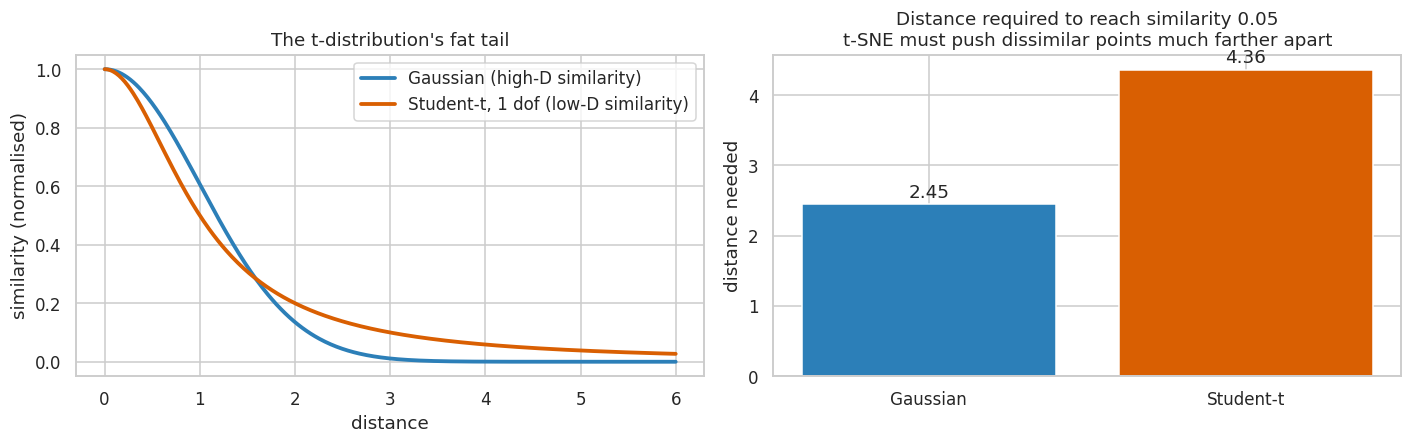

In [ ]:
# See the Gaussian vs t-distribution difference that makes t-SNE work
d = np.linspace(0, 6, 400)
gauss = np.exp(-d ** 2 / 2)
student_t = 1 / (1 + d ** 2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(d, gauss / gauss.max(), lw=2.5, color="#2c7fb8",
             label="Gaussian (high-D similarity)")
axes[0].plot(d, student_t / student_t.max(), lw=2.5, color="#d95f02",
             label="Student-t, 1 dof (low-D similarity)")
axes[0].set_xlabel("distance"); axes[0].set_ylabel("similarity (normalised)")
axes[0].set_title("The t-distribution's fat tail"); axes[0].legend()

target = 0.05
d_gauss = np.sqrt(-2 * np.log(target))
d_t = np.sqrt(1 / target - 1)
axes[1].bar(["Gaussian", "Student-t"], [d_gauss, d_t], color=["#2c7fb8", "#d95f02"])
axes[1].set_ylabel("distance needed")
axes[1].set_title(f"Distance required to reach similarity {target}\n"
                  "t-SNE must push dissimilar points much farther apart")
for i, v in enumerate([d_gauss, d_t]):
    axes[1].text(i, v + 0.1, f"{v:.2f}", ha="center")
fig.tight_layout(); plt.show()

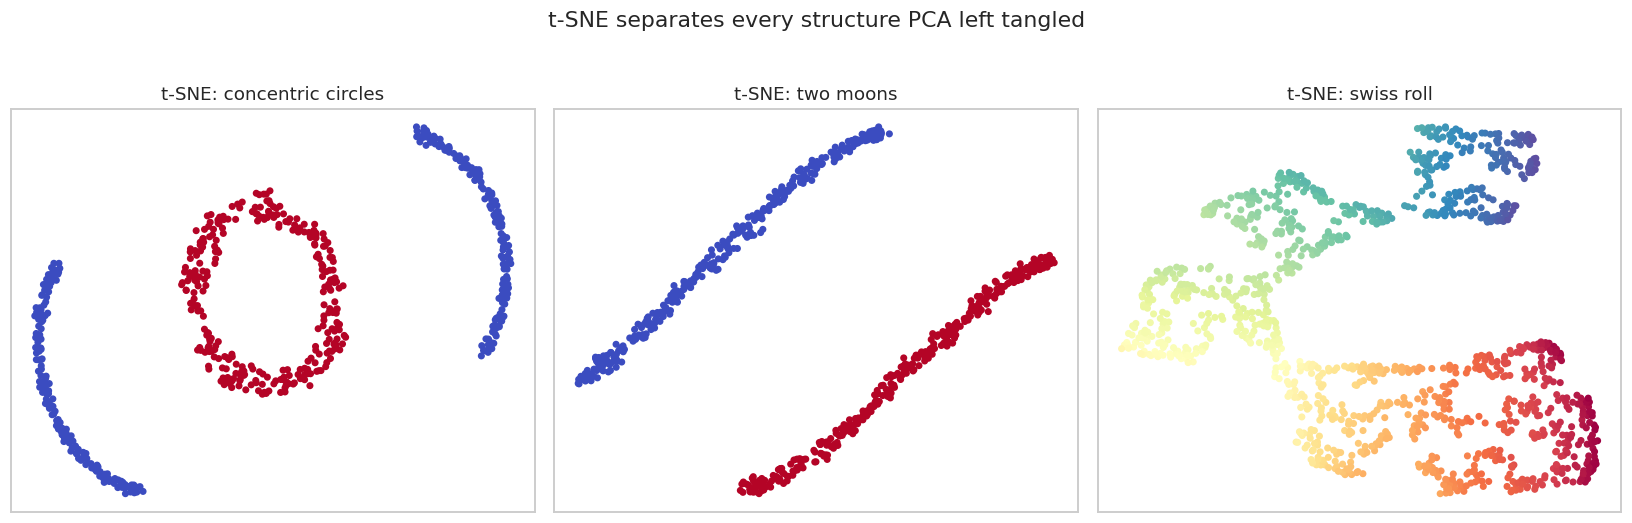

In [ ]:
# t-SNE on the shapes PCA could not unfold
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

for ax, (X_, colr, title) in zip(axes, [
        (X_circ, y_circ, "concentric circles"),
        (X_moon, y_moon, "two moons"),
        (X_roll, color_roll, "swiss roll")]):
    Z = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE,
             init="pca", learning_rate="auto").fit_transform(X_)
    cmap = "coolwarm" if title != "swiss roll" else "Spectral"
    ax.scatter(*Z.T, c=colr, cmap=cmap, s=13)
    ax.set_title(f"t-SNE: {title}")
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle("t-SNE separates every structure PCA left tangled", y=1.03)
fig.tight_layout(); plt.show()

Look at the swiss roll: t-SNE has **unrolled** it, and the colour gradient (position along
the roll) runs smoothly across the map. PCA could never do that.

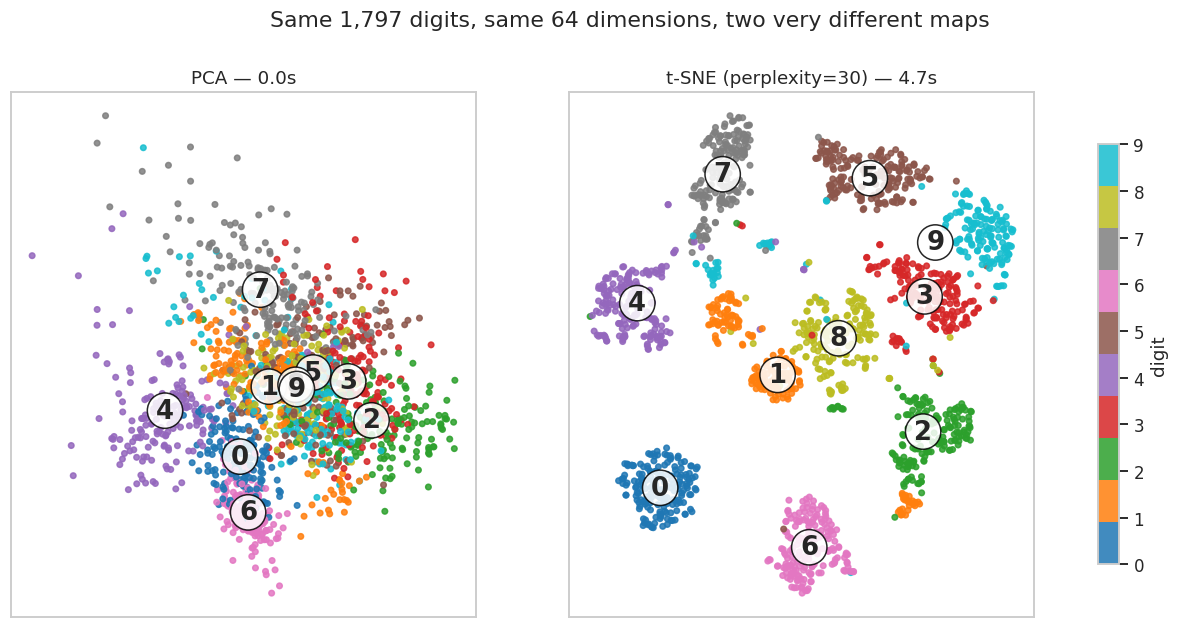

PCA   : 0.00s, explains 21.6% of variance
t-SNE : 4.72s, no variance number exists — it optimises a layout, not a projection


In [ ]:
# The headline comparison: 64-D digits down to 2-D, two ways
t0 = time.perf_counter()
Z_pca_dig = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_dig_s)
t_pca = time.perf_counter() - t0

t0 = time.perf_counter()
Z_tsne_dig = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE,
                  init="pca", learning_rate="auto").fit_transform(X_dig_s)
t_tsne = time.perf_counter() - t0

fig, axes = plt.subplots(1, 2, figsize=(15, 6.2))
for ax, Z, title, secs in [(axes[0], Z_pca_dig, "PCA", t_pca),
                           (axes[1], Z_tsne_dig, "t-SNE (perplexity=30)", t_tsne)]:
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=y_dig, cmap="tab10", s=13, alpha=0.85)
    for digit in range(10):
        cx, cy = Z[y_dig == digit].mean(axis=0)
        ax.text(cx, cy, str(digit), fontsize=17, fontweight="bold",
                ha="center", va="center",
                bbox=dict(boxstyle="circle,pad=0.18", fc="white", ec="black", alpha=0.85))
    ax.set_title(f"{title} — {secs:.1f}s"); ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(sc, ax=axes, label="digit", shrink=0.8)
fig.suptitle("Same 1,797 digits, same 64 dimensions, two very different maps", y=1.0)
plt.show()

print(f"PCA   : {t_pca:.2f}s, explains "
      f"{PCA(n_components=2).fit(X_dig_s).explained_variance_ratio_.sum():.1%} of variance")
print(f"t-SNE : {t_tsne:.2f}s, no variance number exists — it optimises a layout, "
      "not a projection")

In [ ]:
# Quantify what "better separated" means, using the labels t-SNE never saw
print("Silhouette score using the TRUE digit labels as the grouping")
print("(higher = the classes sit in tighter, better-separated regions of the map)\n")
print(f"  original 64-D space : {silhouette_score(X_dig_s, y_dig):.4f}")
print(f"  PCA 2-D             : {silhouette_score(Z_pca_dig, y_dig):.4f}")
print(f"  t-SNE 2-D           : {silhouette_score(Z_tsne_dig, y_dig):.4f}")

# And a trustworthiness-style check: how many of each point's 10 nearest neighbours
# in the ORIGINAL space are still among its 10 nearest in the map?
from sklearn.neighbors import NearestNeighbors

def neighbour_overlap(X_high, X_low, k=10):
    nn_h = NearestNeighbors(n_neighbors=k + 1).fit(X_high).kneighbors(return_distance=False)
    nn_l = NearestNeighbors(n_neighbors=k + 1).fit(X_low).kneighbors(return_distance=False)
    return np.mean([len(set(a) & set(b)) / k for a, b in zip(nn_h, nn_l)])

print(f"\nNeighbour preservation (10-NN overlap with the original 64-D space):")
print(f"  PCA 2-D   : {neighbour_overlap(X_dig_s, Z_pca_dig):.3f}")
print(f"  t-SNE 2-D : {neighbour_overlap(X_dig_s, Z_tsne_dig):.3f}")
print("\nt-SNE wins decisively on LOCAL neighbourhoods — which is exactly what it optimises.")

Silhouette score using the TRUE digit labels as the grouping
(higher = the classes sit in tighter, better-separated regions of the map)

  original 64-D space : 0.1081
  PCA 2-D             : 0.0547
  t-SNE 2-D           : 0.4853

Neighbour preservation (10-NN overlap with the original 64-D space):
  PCA 2-D   : 0.141
  t-SNE 2-D : 0.627

t-SNE wins decisively on LOCAL neighbourhoods — which is exactly what it optimises.


---
# Part F · Perplexity, randomness, and the caveats

## F1 · Perplexity

Perplexity is roughly *"how many neighbours should each point pay attention to"*. It sets
the width of the Gaussian in step 1.

- **Low (5–10)** → very local. Finds fine structure, but can shatter one real group into
  several fake islands.
- **Medium (30–50)** → the usual range. sklearn's default is 30.
- **High (100+)** → more global, blurrier, slower.

**Rule of thumb: perplexity should be well below your number of points** (sklearn requires
`perplexity < n_samples`). Always try two or three values before you believe a picture.

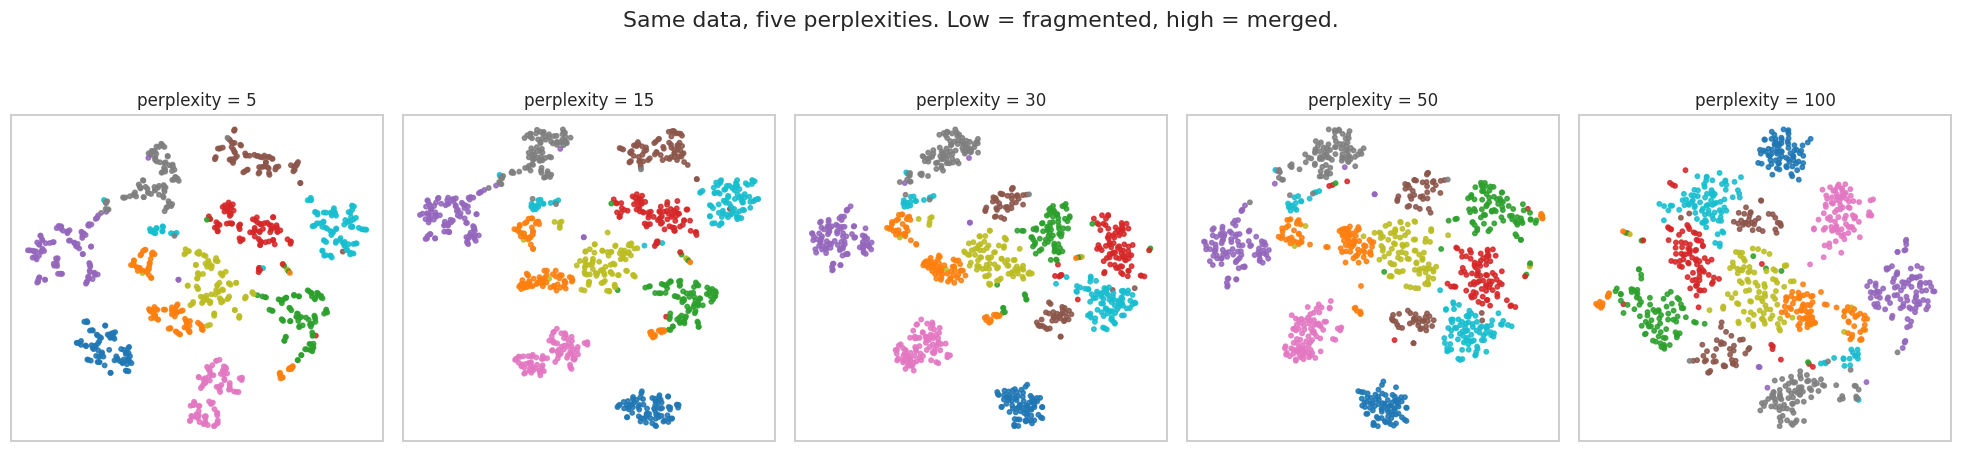

In [ ]:
subset = rng.choice(len(X_dig_s), 900, replace=False)   # smaller = faster for the sweep
Xd_sub, yd_sub = X_dig_s[subset], y_dig[subset]

perps = [5, 15, 30, 50, 100]
fig, axes = plt.subplots(1, len(perps), figsize=(18, 3.9))
for ax, perp in zip(axes, perps):
    Z = TSNE(n_components=2, perplexity=perp, random_state=RANDOM_STATE,
             init="pca", learning_rate="auto").fit_transform(Xd_sub)
    ax.scatter(*Z.T, c=yd_sub, cmap="tab10", s=8, alpha=0.85)
    ax.set_title(f"perplexity = {perp}", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Same data, five perplexities. Low = fragmented, high = merged.", y=1.05)
fig.tight_layout(); plt.show()

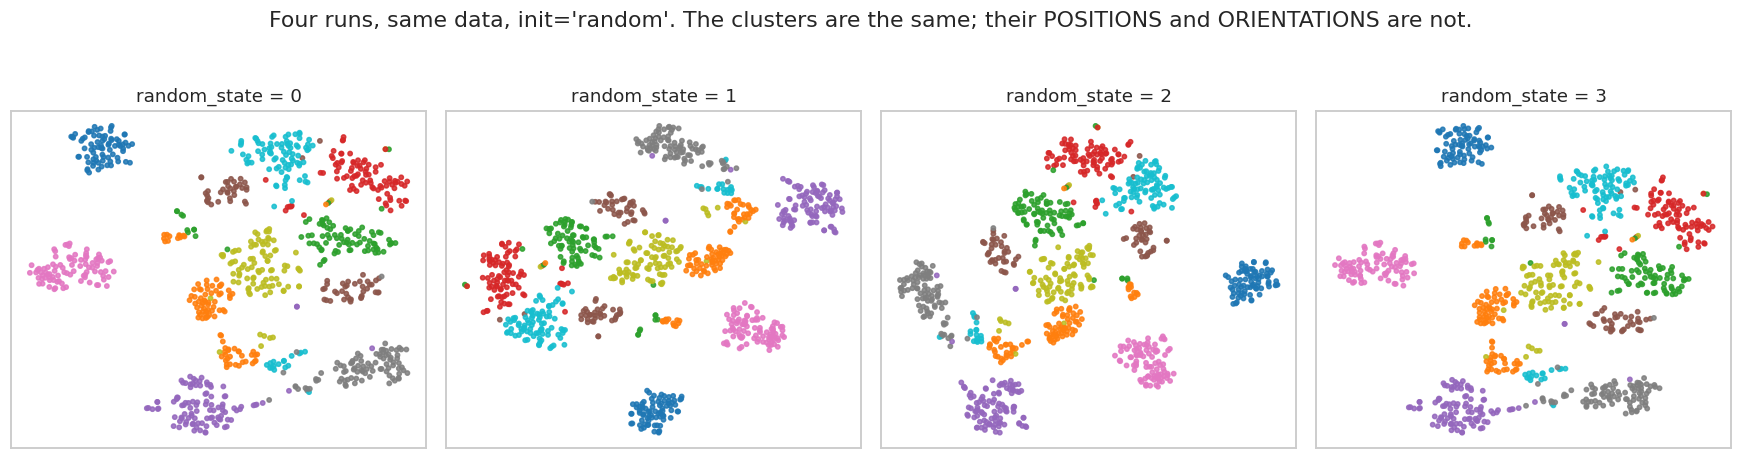

Always set random_state, and use init='pca' (the modern default) for a more
stable, reproducible layout that also preserves a bit of global structure.


In [ ]:
# t-SNE is STOCHASTIC: a different seed gives a different-looking map
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, seed in zip(axes, [0, 1, 2, 3]):
    Z = TSNE(n_components=2, perplexity=30, random_state=seed,
             init="random", learning_rate="auto").fit_transform(Xd_sub)
    ax.scatter(*Z.T, c=yd_sub, cmap="tab10", s=8, alpha=0.85)
    ax.set_title(f"random_state = {seed}"); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Four runs, same data, init='random'. The clusters are the same; "
             "their POSITIONS and ORIENTATIONS are not.", y=1.04)
fig.tight_layout(); plt.show()

print("Always set random_state, and use init='pca' (the modern default) for a more")
print("stable, reproducible layout that also preserves a bit of global structure.")

## F2 · The caveats — read this before you put a t-SNE plot in a report

| Caveat | What it means |
|---|---|
| **Cluster *sizes* are meaningless** | t-SNE expands sparse regions and compresses dense ones. A big blob is not a big group. |
| **Distances *between* clusters are meaningless** | Two clusters on opposite sides of the plot are not necessarily more different than two adjacent ones. Only *within*-cluster proximity is trustworthy. |
| **It can invent clusters** | Random noise, at low perplexity, will happily split into convincing-looking "groups". |
| **No `transform()` for new data** | t-SNE has `fit_transform` only. You cannot embed a new point without re-running the whole thing. **So it can never be a preprocessing step in a prediction pipeline.** |
| **Stochastic** | Different seeds → different pictures. Set `random_state`. |
| **Slow** | Roughly O(n log n) with Barnes-Hut, but still minutes for 100k+ points. PCA to ~50 dims first. |
| **Not for `n_components > 3`** | The Barnes-Hut algorithm only supports 2 or 3 output dimensions. |

Let's prove the scariest one: **t-SNE finds "clusters" in pure noise.**

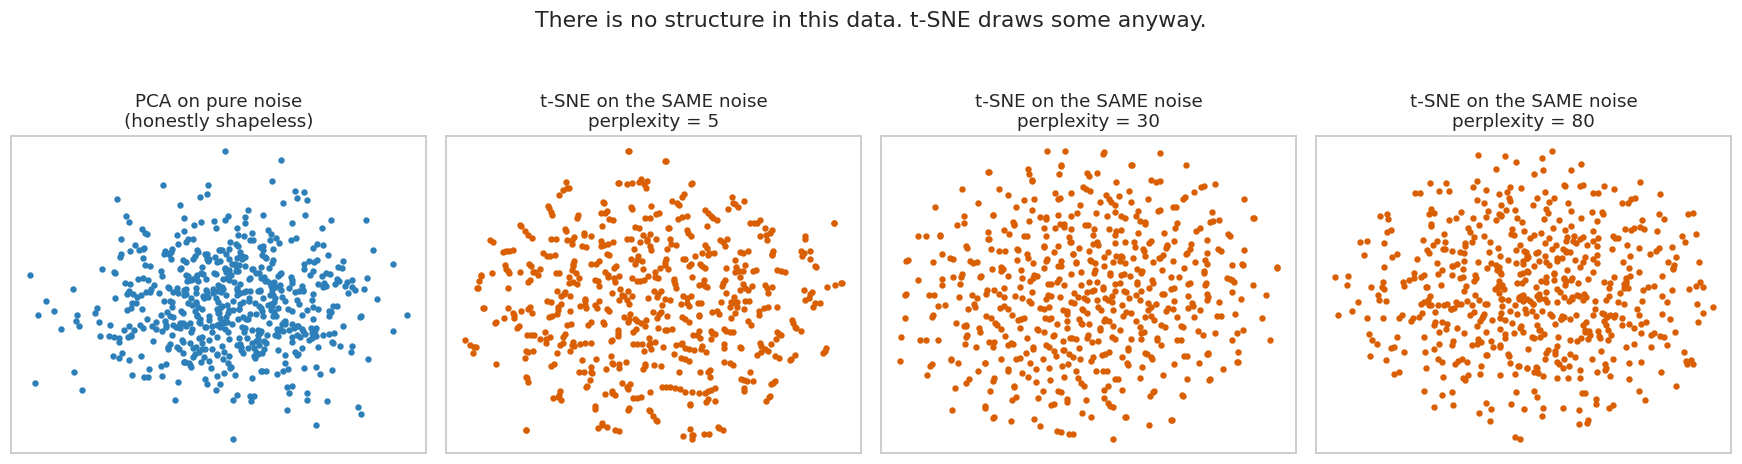

Lesson: a t-SNE plot is a HYPOTHESIS GENERATOR, never evidence on its own.
Validate any group you see with the original features, a clustering metric,
or a supervised test — exactly as we did in Week 9-10.


In [ ]:
pure_noise = rng.normal(0, 1, size=(600, 40))     # no structure whatsoever

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].scatter(*PCA(n_components=2).fit_transform(pure_noise).T,
                s=10, color="#2c7fb8")
axes[0].set_title("PCA on pure noise\n(honestly shapeless)")
for ax, perp in zip(axes[1:], [5, 30, 80]):
    Z = TSNE(n_components=2, perplexity=perp, random_state=RANDOM_STATE,
             init="pca", learning_rate="auto").fit_transform(pure_noise)
    ax.scatter(*Z.T, s=10, color="#d95f02")
    ax.set_title(f"t-SNE on the SAME noise\nperplexity = {perp}")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("There is no structure in this data. t-SNE draws some anyway.", y=1.05)
fig.tight_layout(); plt.show()

print("Lesson: a t-SNE plot is a HYPOTHESIS GENERATOR, never evidence on its own.")
print("Validate any group you see with the original features, a clustering metric,")
print("or a supervised test — exactly as we did in Week 9-10.")

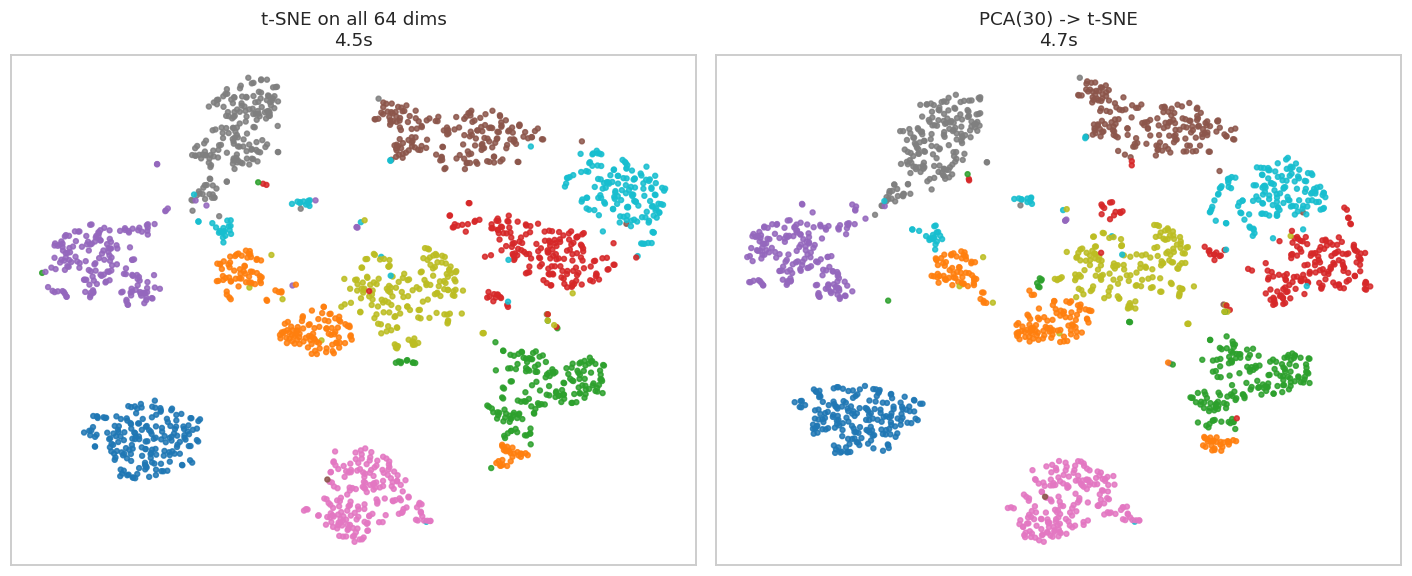

Practically identical maps. On a dataset with thousands of features
(gene expression, TF-IDF, embeddings) the PCA step is the difference between
minutes and hours — and it denoises before t-SNE ever sees the data.


In [ ]:
# And the practical recipe everyone actually uses: PCA first, then t-SNE
t0 = time.perf_counter()
Z_direct = TSNE(2, perplexity=30, random_state=RANDOM_STATE,
                init="pca", learning_rate="auto").fit_transform(X_dig_s)
t_direct = time.perf_counter() - t0

t0 = time.perf_counter()
X_pre = PCA(n_components=30, random_state=RANDOM_STATE).fit_transform(X_dig_s)
Z_two_step = TSNE(2, perplexity=30, random_state=RANDOM_STATE,
                  init="pca", learning_rate="auto").fit_transform(X_pre)
t_two = time.perf_counter() - t0

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
for ax, Z, title, secs in [(axes[0], Z_direct, "t-SNE on all 64 dims", t_direct),
                           (axes[1], Z_two_step, "PCA(30) -> t-SNE", t_two)]:
    ax.scatter(*Z.T, c=y_dig, cmap="tab10", s=10, alpha=0.85)
    ax.set_title(f"{title}\n{secs:.1f}s"); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); plt.show()

print(f"Practically identical maps. On a dataset with thousands of features")
print(f"(gene expression, TF-IDF, embeddings) the PCA step is the difference between")
print(f"minutes and hours — and it denoises before t-SNE ever sees the data.")

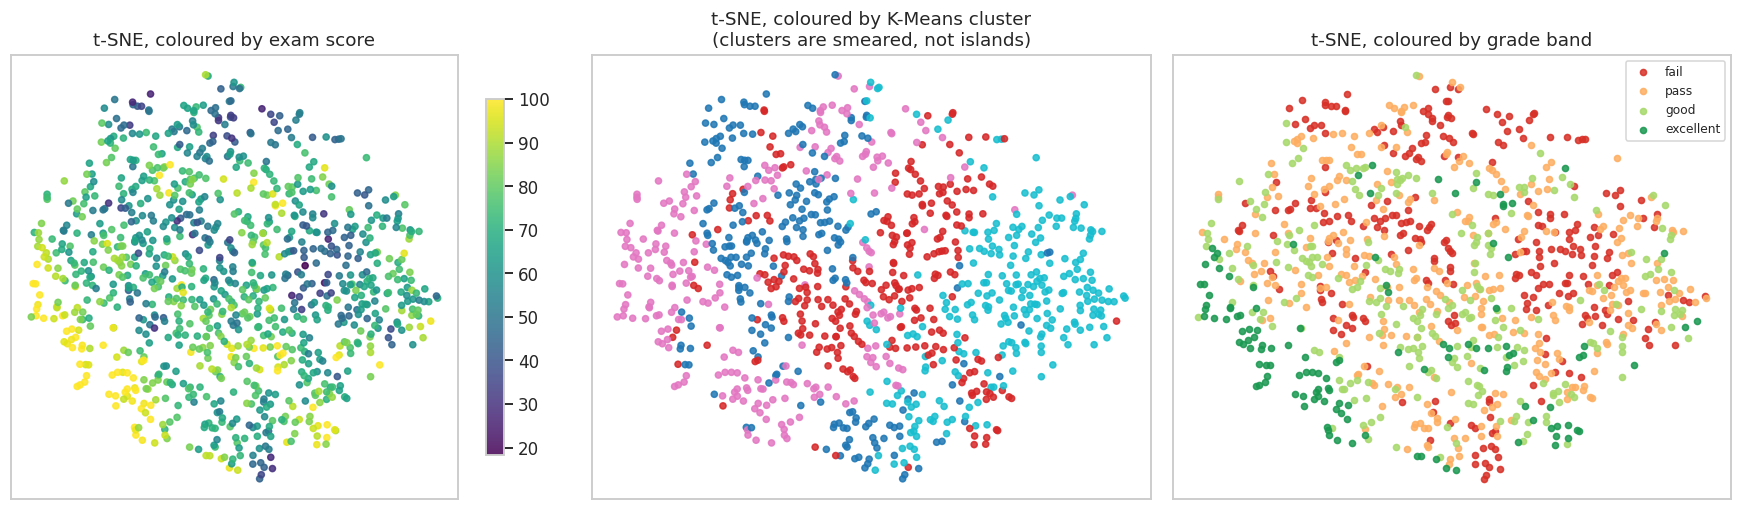

Compare with the digits plot. There, t-SNE produced ten clean islands because ten
genuinely distinct groups exist. Here it produces one continuous cloud with a
colour GRADIENT across it — the honest picture of a continuum.

This is t-SNE being useful: it did not manufacture clusters that aren't there,
and the smooth score gradient confirms the Week 9-10 conclusion.


In [ ]:
# t-SNE on OUR student data. Prediction from Week 9-10: no real clusters exist.
Z_tsne_stu = TSNE(n_components=2, perplexity=40, random_state=RANDOM_STATE,
                  init="pca", learning_rate="auto").fit_transform(X_stu_s)

km_labels = KMeans(4, n_init=10, random_state=RANDOM_STATE).fit_predict(X_stu_s)
grade = np.asarray(pd.cut(y_stu, [-1, 60, 75, 90, 101],
                          labels=["fail", "pass", "good", "excellent"]))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
sc = axes[0].scatter(*Z_tsne_stu.T, c=y_stu, cmap="viridis", s=16, alpha=0.85)
axes[0].set_title("t-SNE, coloured by exam score")
fig.colorbar(sc, ax=axes[0], shrink=0.8)

axes[1].scatter(*Z_tsne_stu.T, c=km_labels, cmap="tab10", s=16, alpha=0.85)
axes[1].set_title("t-SNE, coloured by K-Means cluster\n(clusters are smeared, not islands)")

for g, colr in zip(["fail", "pass", "good", "excellent"],
                   ["#d73027", "#fdae61", "#a6d96a", "#1a9850"]):
    m = grade == g
    axes[2].scatter(Z_tsne_stu[m, 0], Z_tsne_stu[m, 1], c=colr, s=16, alpha=0.85, label=g)
axes[2].set_title("t-SNE, coloured by grade band"); axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); plt.show()

print("Compare with the digits plot. There, t-SNE produced ten clean islands because ten")
print("genuinely distinct groups exist. Here it produces one continuous cloud with a")
print("colour GRADIENT across it — the honest picture of a continuum.")
print("\nThis is t-SNE being useful: it did not manufacture clusters that aren't there,")
print("and the smooth score gradient confirms the Week 9-10 conclusion.")

---
# Part G · PCA vs t-SNE — choosing between them

| | **PCA** | **t-SNE** |
|---|---|---|
| Type | linear projection | non-linear manifold learning |
| Preserves | global variance / large distances | local neighbourhoods |
| Deterministic? | yes | **no** — set `random_state` |
| `transform()` for new data? | **yes** | **no** (`fit_transform` only) |
| Use in an ML pipeline? | **yes** — a standard preprocessing step | **no** — visualisation only |
| Output dimensions | any `k` | 2 or 3 |
| Speed | very fast, O(n·d²) | slow, O(n log n) with Barnes-Hut |
| Interpretable axes? | yes — loadings are feature recipes | **no** — axes mean nothing |
| Invertible? | yes (`inverse_transform`) | no |
| Main hyperparameter | `n_components` | `perplexity` |
| Fails when | structure is non-linear | you need global geometry or new-data mapping |

### The decision, in practice

**Use PCA when** you want to compress features before modelling, denoise, speed up
training, remove multicollinearity, or you need an interpretable, reversible, reusable
transform.

**Use t-SNE when** you want to *look at* high-dimensional data and ask "are there groups in
here?" — exploratory analysis, sanity-checking embeddings, presenting a dataset.

**Use both:** PCA to ~30–50 dimensions for speed and denoising, then t-SNE for the picture.
That two-step is the standard professional recipe.

### A word on UMAP

**UMAP** (Uniform Manifold Approximation and Projection) is the modern alternative to
t-SNE. It is substantially faster, preserves more *global* structure (so between-cluster
distances mean a little more), and — importantly — **does have a `transform()` method**, so
it can embed new points and be used in a pipeline. It is not in scikit-learn; install it
with `pip install umap-learn`.

If you are doing this in 2026, reach for UMAP first and keep t-SNE as the cross-check.
The intuition you built here transfers directly: both are neighbourhood-preserving
manifold methods, and every caveat in Part F applies to UMAP too.

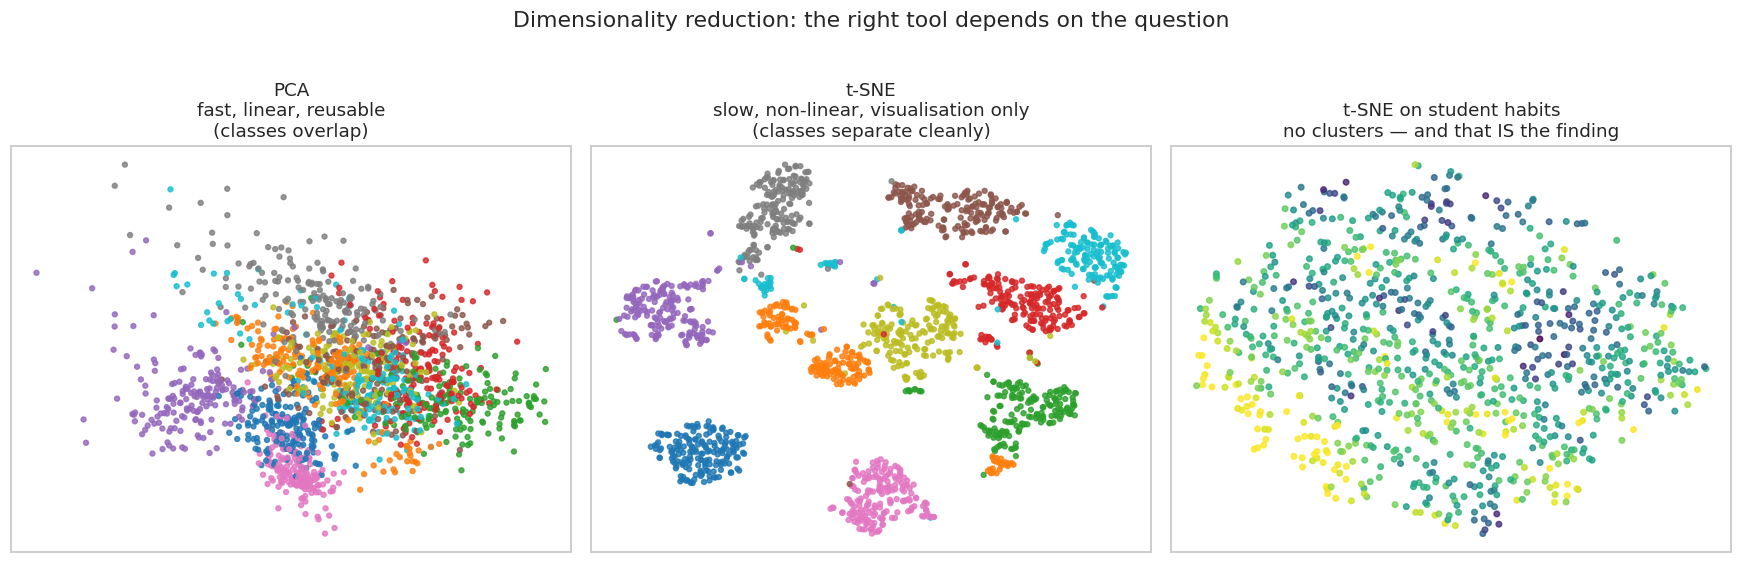

In [ ]:
# One figure to remember the whole notebook by
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(*Z_pca_dig.T, c=y_dig, cmap="tab10", s=10, alpha=0.8)
axes[0].set_title("PCA\nfast, linear, reusable\n(classes overlap)")

axes[1].scatter(*Z_tsne_dig.T, c=y_dig, cmap="tab10", s=10, alpha=0.8)
axes[1].set_title("t-SNE\nslow, non-linear, visualisation only\n(classes separate cleanly)")

axes[2].scatter(*Z_tsne_stu.T, c=y_stu, cmap="viridis", s=13, alpha=0.8)
axes[2].set_title("t-SNE on student habits\nno clusters — and that IS the finding")

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Dimensionality reduction: the right tool depends on the question", y=1.02)
fig.tight_layout(); plt.show()

---
## Mini-challenge

1. Run PCA on the **full 16-column student dataset** (one-hot encode the categoricals
   first, as in Week 7–8). Do the components become more interpretable when there are more
   correlated features?
2. Build a pipeline `StandardScaler → PCA(k) → LogisticRegression` and use `GridSearchCV`
   (Week 9–10) to tune `pca__n_components` and `clf__C` **together**. Does the best `k` come
   out where you expected?
3. Take the digits, keep only classes 3, 5 and 8 (the ones t-SNE placed closest together),
   and re-run both methods. Can PCA separate them at all?
4. Implement the **neighbour-overlap** metric from Part E as a function and use it to
   compare PCA at k = 2, 5, 10, 20 against t-SNE. At what `k` does PCA catch up?
5. `pip install umap-learn`, run UMAP on the digits, and compare it with t-SNE on speed,
   separation, and whether `transform()` on held-out digits lands them in the right place.
6. Cluster the **t-SNE output** with K-Means and then cluster the original 64-D data with
   K-Means. Compare with `adjusted_rand_score`. Then explain why clustering t-SNE output is
   usually a **bad idea** despite how good it looks.

In [ ]:
# --- your workspace for the mini-challenge ---

---
## Recap

### PCA
- Rotates the axes to point along maximum variance; components are the eigenvectors of the
  covariance matrix, eigenvalues are the variance along each.
- **Always standardise first.** Signs are arbitrary; magnitudes are not.
- `PCA(n_components=0.95)` picks `k` for you by variance target.
- Loadings tell you what a component *means*; `inverse_transform` tells you what you lost.
- Improves accuracy when features are noisy or redundant (0.76 → 0.89 for KNN on the noisy
  digits); on already-clean features it buys speed, not accuracy. Belongs **inside a
  Pipeline** so it is fitted per fold.
- Cannot represent curved structure — that is a hard limitation, not a tuning problem.

### t-SNE
- Converts distances to neighbour *probabilities* in high-D (Gaussian) and low-D
  (Student-t), then minimises the KL divergence between them by gradient descent.
- The heavy-tailed t-distribution solves the crowding problem by forcing dissimilar points
  far apart.
- **Perplexity** ≈ effective number of neighbours; try 5, 30 and 50 before trusting a plot.
- Cluster sizes and between-cluster distances **mean nothing**. It can invent clusters in
  pure noise.
- No `transform()`, so it is **never** a preprocessing step — visualisation only.
- Standard recipe: `StandardScaler → PCA(30–50) → TSNE(2)`.

### Results from this notebook
| Finding | Number |
|---|---|
| Digits: components needed for 95% of the variance | 40 of 64 |
| Digits: 10-NN neighbour preservation in 2-D | PCA 0.14 vs t-SNE **0.63** |
| Digits: silhouette by true label in 2-D | PCA 0.05 vs t-SNE **0.49** |
| Clean digits: KNN with PCA(40) vs without | 0.977 vs 0.979 — same accuracy, **30× faster** |
| Digits + 300 noise dims: KNN with PCA(10) vs without | 0.89 vs 0.76 — **PCA rescues it** |
| Students: PCA before logistic regression | **hurts** — only 7 independent features |
| Students: t-SNE map | one continuous cloud with a score gradient, no islands |

**That last row is the most important one in the notebook.** t-SNE on the digits produced
ten clean islands because ten real groups exist. On the student habits it produced a smooth
cloud, because the habits form a continuum. A visualisation method that tells you "there is
nothing here" when there is nothing here is doing its job — and knowing the difference is
what separates reading a plot from being fooled by one.

**Next up:** you now have the full Weeks 3–12 arc — Python, maths, supervised models,
evaluation, and unsupervised learning including dimensionality reduction.